In [10]:
from astropy.io import fits

oiii_hdul = fits.open("SNR_OIII.fits")
oiiic_hdul = fits.open("SNR_OIIIC.fits")

oiii_data = oiii_hdul["SCI"].data
oiiic_data = oiiic_hdul["SCI"].data

oiii_header = oiii_hdul[0].header
oiiic_header = oiiic_hdul[0].header

In [11]:
# calculate exposure time
oiii_time_sec = oiii_header["EXPOSURE"] * oiii_header["NCOMBINE"] 
oiiic_time_sec = oiiic_header["EXPOSURE"] * oiiic_header["NCOMBINE"] 

print(oiii_time_sec, oiiic_time_sec)

6480.0 6480.0


In [14]:
# normalize images

oiii_data = oiii_data / oiii_time_sec
oiiic_data = oiiic_data / oiiic_time_sec

# update headers
oiii_header["EXPOSURE"] = 1
oiiic_header["EXPOSURE"] = 1

# save output
fits.writeto("normalized_OIII.fits", oiii_data, header=oiii_header, overwrite=True)
fits.writeto("normalized_OIIIC.fits", oiiic_data, header=oiiic_header, overwrite=True)

In [ ]:
# align images again
import astroalign as aa
import numpy as np

source = np.asarray(oiiic_data, dtype=np.float32)
target = np.asarray(oiii_data, dtype=np.float32)

oiiic_aligned, footprint = aa.register(source, target)


<frozen importlib._bootstrap>:241: FutureWarning: 
The `sep-pjw` package has reverted to the original `sep` package name. Bug
fixes and additional enhancements will not be released for `sep-pjw`, and
users of this package should update their dependencies to `sep>=1.4.0`.



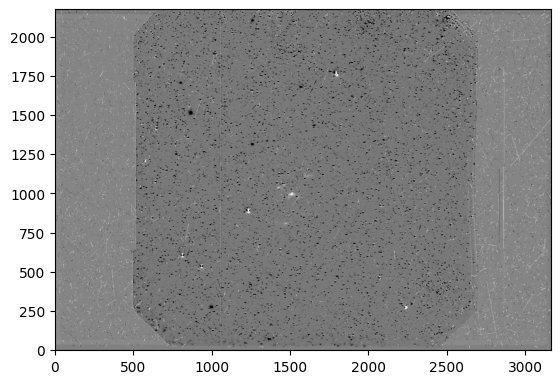

In [71]:
import matplotlib.pyplot as plt
import numpy as np

diff = oiii_data - oiiic_aligned * 0.5
# diff[1050:1060, 1000:1040]

plt.imshow(diff, cmap='gray', origin='lower', vmin=np.percentile(diff,1), vmax=np.percentile(diff,99.5))
plt.show()

# fits.writeto("subtracted_scaled.fits", diff, oiii_header, overwrite=True)

In [72]:
from astropy.stats import sigma_clipped_stats
mean, median, std = sigma_clipped_stats(diff[1000:1100, 1000:1100])
print(std)

7.860145e-11


In [ ]:
# from astropy.stats import sigma_clipped_stats

# for scale in [0.3, 0.4, 0.5, 0.6]:

#     diff = oiii_data - scale * oiiic_aligned

#     mean, median, std = sigma_clipped_stats(diff)

#     print(scale, mean, median, std)

0.3 2.711932e-10 3.1350428e-10 1.7600796e-10
0.4 1.0778319e-10 1.03681286e-10 5.7105515e-11
0.5 -4.0616226e-11 -5.670464e-11 1.0841996e-10
0.6 -2.029909e-10 -2.6139402e-10 2.3833469e-10
